# Feature Sparsity & Correlations: Toy Models → Deep Autoencoders

**Part 1**: Reproduce key Toy Models of Superposition plots (Elhage et al.)
- W^TW heatmap showing superposition onset as sparsity increases
- Feature dimensionality metric D_i across sparsity levels
- Phase diagram: n/m vs sparsity

**Part 2**: How do sparsity and correlation structure interact with depth?
- Same sweeps with l=1 (linear encoder) vs l=2,3 (nonlinear)
- Correlated features: does superposition change when features share structure?
- Where does nonlinear encoding become beneficial?

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import pandas as pd

from core import (
    Autoencoder, generate_sparse_data, generate_correlated_features,
    train_autoencoder, get_feature_importance, measure_encoding_linearity,
    run_experiment, run_experiment_multi_seed, device
)

print(f"Using device: {device}")

Using device: cpu


---
# Part 1: Reproducing Toy Models of Superposition

## 1.1 W^TW Visualization Across Sparsity

The key plot from the paper: train models at different sparsity levels and visualize the Gram matrix W^TW of the encoder weights. This reveals:
- **No superposition** (low S): W^TW ≈ diagonal — features orthogonal, some zeroed out
- **Superposition** (high S): W^TW has off-diagonal structure — features interfere

Setup: n=20 features, m=5 bottleneck, l=1 (linear encoder with tied weights), importance I_i = 0.7^i

In [2]:
# Train models across a range of sparsity values
n, m = 20, 5
S_values = [0.0, 0.5, 0.7, 0.8, 0.9, 0.95, 0.97, 0.99]
models_by_S = {}

for S in tqdm(S_values, desc="Training across sparsity"):
    result = run_experiment_multi_seed(
        n=n, m=m, l=1,
        n_seeds=50,
        S=S,
        n_steps=10000,
        importance_decay=0.7,
        verbose=False
    )
    models_by_S[S] = result
    print(f"S={S:.2f}: loss={result['final_loss']:.6f}, "
          f"seeds_tried={result['seeds_tried']}, best_seed={result['best_seed']}")

Training across sparsity:   0%|          | 0/8 [00:00<?, ?it/s]

Training across sparsity:  12%|█▎        | 1/8 [02:22<16:35, 142.27s/it]

S=0.00: loss=0.002317, seeds_tried=50, best_seed=14


Training across sparsity:  25%|██▌       | 2/8 [04:38<13:51, 138.62s/it]

S=0.50: loss=0.002780, seeds_tried=50, best_seed=4


...

Training across sparsity:  88%|████████▊ | 7/8 [24:44<04:21, 261.09s/it]

S=0.97: loss=0.000065, seeds_tried=50, best_seed=10


Training across sparsity: 100%|██████████| 8/8 [29:22<00:00, 266.22s/it]

Training across sparsity: 100%|██████████| 8/8 [29:22<00:00, 220.26s/it]

S=0.99: loss=0.000015, seeds_tried=50, best_seed=16


/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_18095/395777831.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


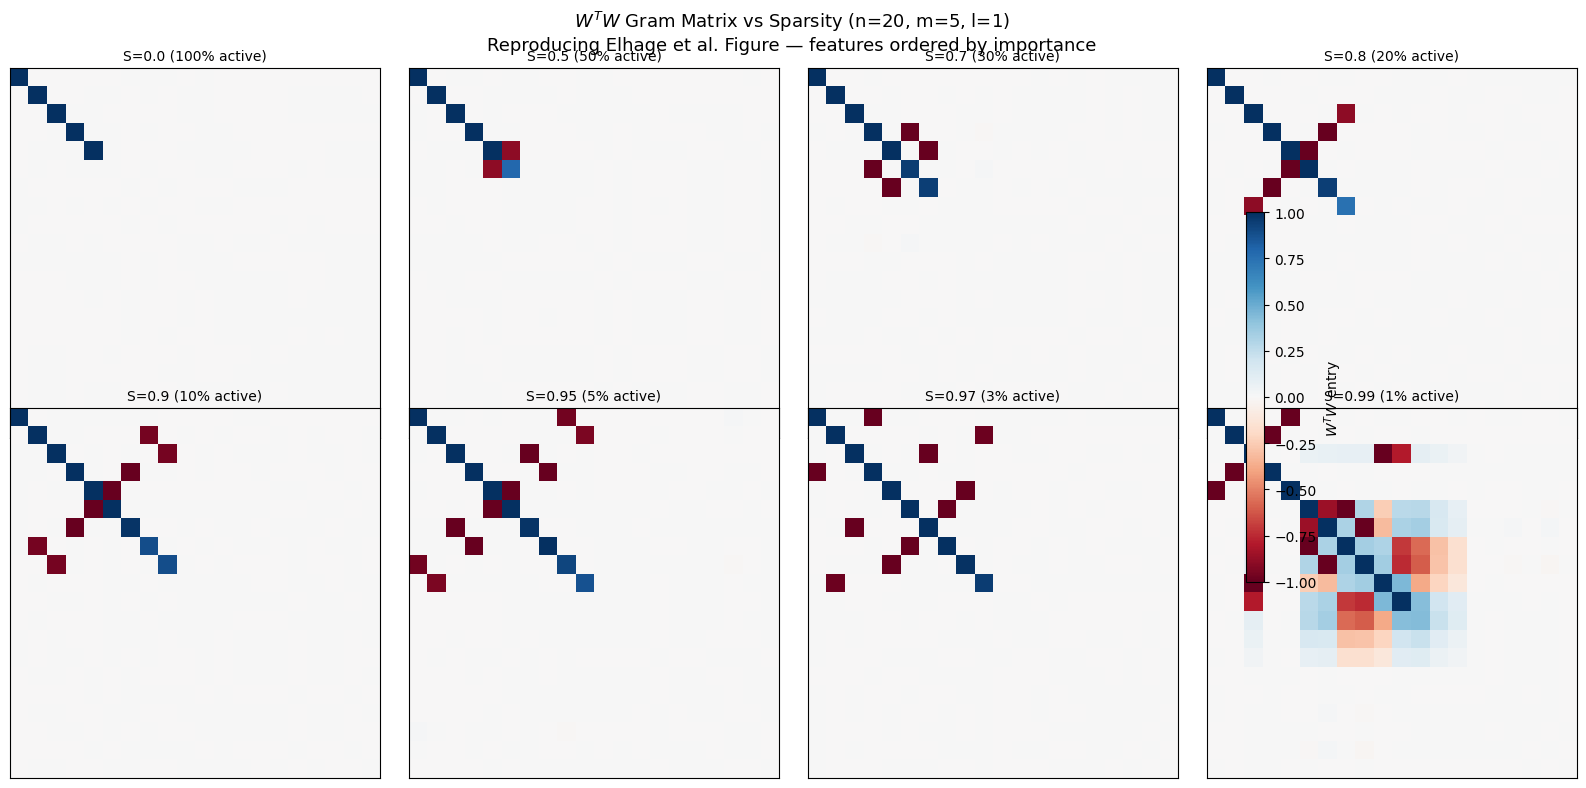

Expected: As S increases, off-diagonal structure appears (superposition).
Low S: only top-m features have nonzero rows/cols (no superposition).
High S: all features represented, with interference (superposition).


In [3]:
# Plot W^TW heatmaps (the signature Toy Models figure)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, S in enumerate(S_values):
    model = models_by_S[S]['model']
    # Get encoder weight matrix W (shape: m x n)
    W = list(model.encoder.parameters())[0].detach().cpu().numpy()
    # W^TW is the Gram matrix (shape: n x n)
    WtW = W.T @ W
    
    ax = axes[idx]
    im = ax.imshow(WtW, cmap='RdBu', vmin=-1, vmax=1, aspect='equal')
    ax.set_title(f'S={S} ({100*(1-S):.0f}% active)', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.6, label='$W^TW$ entry')
fig.suptitle(f'$W^TW$ Gram Matrix vs Sparsity (n={n}, m={m}, l=1)\n'
             f'Reproducing Elhage et al. Figure — features ordered by importance',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Expected: As S increases, off-diagonal structure appears (superposition).")
print("Low S: only top-m features have nonzero rows/cols (no superposition).")
print("High S: all features represented, with interference (superposition).")

## 1.2 Feature Dimensionality

The paper defines a per-feature "dimensionality" metric:

$$D_i = \frac{\|W_i\|^2}{\sum_j (W_i \cdot W_j)^2 / \|W_j\|^2}$$

Wait — let me use the actual paper's definition more carefully. The paper tracks:
- **Feature benefit** $B_i = 1 - L_i / L_i^{\text{no feature}}$: how much including feature i reduces loss
- Features are either "represented" (B_i > threshold) or "not represented"
- The total number of represented features tells us about superposition

Simpler and more directly informative: plot the diagonal of W^TW (feature norms squared) vs feature index, for each sparsity level.

<>:13: SyntaxWarning: invalid escape sequence '\|'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\|'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_18095/513725261.py:13: SyntaxWarning: invalid escape sequence '\|'
  ax.set_ylabel('$\|w_i\|^2$')
/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_18095/513725261.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sum_i \|w_i\|^2$')


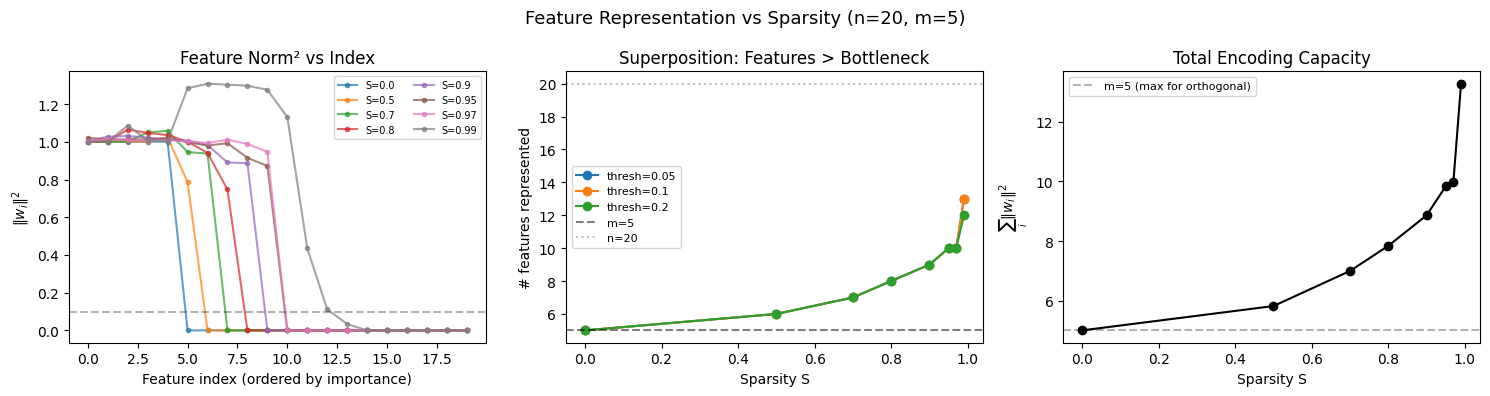

Key observation: At low sparsity, only ~5 features represented (orthogonal).
At high sparsity, more than 5 features represented = superposition.


In [4]:
# Feature norms and representation across sparsity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Feature norms (diagonal of W^TW) vs feature index
ax = axes[0]
for S in S_values:
    model = models_by_S[S]['model']
    W = list(model.encoder.parameters())[0].detach().cpu().numpy()
    norms_sq = np.diag(W.T @ W)  # ||w_i||^2
    ax.plot(range(n), norms_sq, 'o-', markersize=3, label=f'S={S}', alpha=0.7)

ax.set_xlabel('Feature index (ordered by importance)')
ax.set_ylabel('$\|w_i\|^2$')
ax.set_title('Feature Norm² vs Index')
ax.legend(fontsize=7, ncol=2)
ax.axhline(y=0.1, color='k', linestyle='--', alpha=0.3, label='threshold')

# Plot 2: Number of "represented" features (norm > threshold) vs sparsity
ax = axes[1]
thresholds = [0.05, 0.1, 0.2]
for thresh in thresholds:
    n_represented = []
    for S in S_values:
        model = models_by_S[S]['model']
        W = list(model.encoder.parameters())[0].detach().cpu().numpy()
        norms_sq = np.diag(W.T @ W)
        n_represented.append(np.sum(norms_sq > thresh))
    ax.plot(S_values, n_represented, 'o-', label=f'thresh={thresh}')

ax.axhline(y=m, color='k', linestyle='--', alpha=0.5, label=f'm={m}')
ax.axhline(y=n, color='gray', linestyle=':', alpha=0.5, label=f'n={n}')
ax.set_xlabel('Sparsity S')
ax.set_ylabel('# features represented')
ax.set_title('Superposition: Features > Bottleneck')
ax.legend(fontsize=8)

# Plot 3: Total "capacity" = sum of norms squared
ax = axes[2]
total_capacity = []
for S in S_values:
    model = models_by_S[S]['model']
    W = list(model.encoder.parameters())[0].detach().cpu().numpy()
    total_capacity.append(np.sum(np.diag(W.T @ W)))
ax.plot(S_values, total_capacity, 'ko-')
ax.set_xlabel('Sparsity S')
ax.set_ylabel('$\sum_i \|w_i\|^2$')
ax.set_title('Total Encoding Capacity')
ax.axhline(y=m, color='k', linestyle='--', alpha=0.3, label=f'm={m} (max for orthogonal)')
ax.legend(fontsize=8)

plt.suptitle(f'Feature Representation vs Sparsity (n={n}, m={m})', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Key observation: At low sparsity, only ~{m} features represented (orthogonal).")
print(f"At high sparsity, more than {m} features represented = superposition.")

## 1.3 Phase Diagram: Sparsity vs Compression

Sweep both sparsity S and the n/m ratio. Measure fraction of features represented.
This reproduces the paper's main phase diagram showing where superposition lives.

In [5]:
# Phase diagram: sweep S and m for fixed n
n_fixed = 20
m_values = [2, 5, 10, 15, 18, 20]
S_sweep = [0.0, 0.5, 0.7, 0.8, 0.9, 0.95, 0.97, 0.99]

phase_data = []

for m_val in tqdm(m_values, desc="m sweep"):
    for S in S_sweep:
        result = run_experiment_multi_seed(
            n=n_fixed, m=m_val, l=1,
            n_seeds=30,
            S=S,
            n_steps=10000,
            importance_decay=0.7,
            verbose=False
        )
        
        model = result['model']
        W = list(model.encoder.parameters())[0].detach().cpu().numpy()
        norms_sq = np.diag(W.T @ W)
        
        # Fraction of features with nonzero representation
        frac_represented = np.mean(norms_sq > 0.1)
        # Superposition ratio: represented features / bottleneck dim
        n_represented = np.sum(norms_sq > 0.1)
        superposition_ratio = n_represented / m_val
        
        phase_data.append({
            'n': n_fixed, 'm': m_val, 'S': S,
            'n_over_m': n_fixed / m_val,
            'frac_represented': frac_represented,
            'n_represented': n_represented,
            'superposition_ratio': superposition_ratio,
            'final_loss': result['final_loss']
        })

phase_df = pd.DataFrame(phase_data)
print(f"Sweep complete: {len(phase_data)} experiments")

m sweep:   0%|          | 0/6 [00:00<?, ?it/s]

m sweep:  17%|█▋        | 1/6 [19:43<1:38:39, 1183.95s/it]

m sweep:  33%|███▎      | 2/6 [43:04<1:27:26, 1311.65s/it]

m sweep:  50%|█████     | 3/6 [1:00:06<58:58, 1179.34s/it]

m sweep:  67%|██████▋   | 4/6 [1:13:48<34:36, 1038.21s/it]

m sweep:  83%|████████▎ | 5/6 [1:29:08<16:35, 995.38s/it] 

m sweep: 100%|██████████| 6/6 [1:40:34<00:00, 890.45s/it]

m sweep: 100%|██████████| 6/6 [1:40:34<00:00, 1005.83s/it]

Sweep complete: 48 experiments


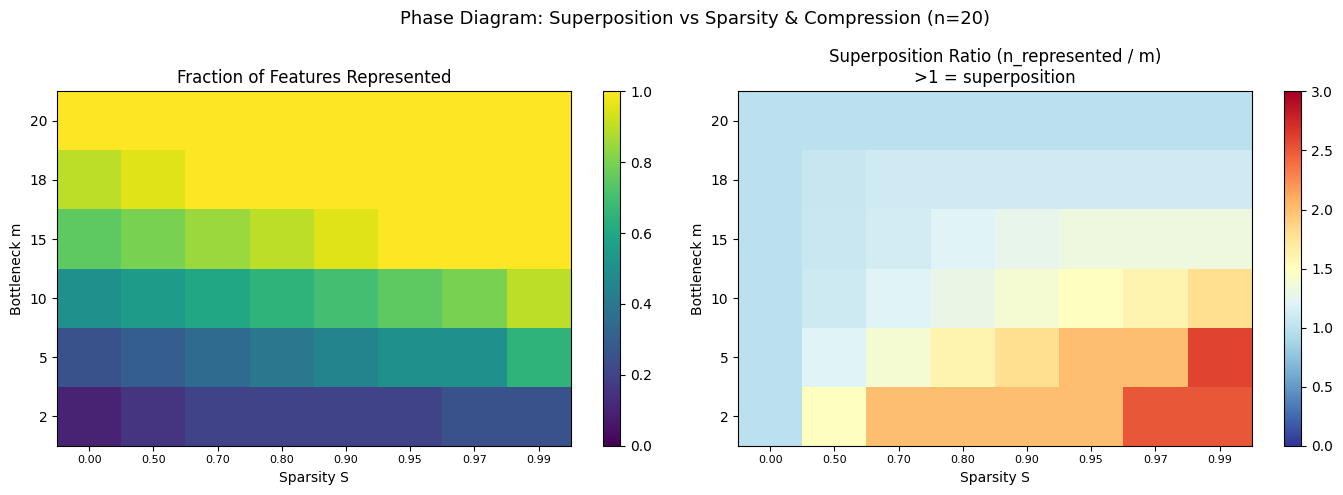

Expected: Superposition appears in upper-right (high S, low m).
When m ≈ n, no need for superposition regardless of sparsity.


In [6]:
# Phase diagram heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fraction of features represented
ax = axes[0]
pivot = phase_df.pivot(index='m', columns='S', values='frac_represented')
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', origin='lower',
               vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{s:.2f}' for s in pivot.columns], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Sparsity S')
ax.set_ylabel('Bottleneck m')
ax.set_title('Fraction of Features Represented')
fig.colorbar(im, ax=ax)

# Plot 2: Superposition ratio (>1 means superposition)
ax = axes[1]
pivot2 = phase_df.pivot(index='m', columns='S', values='superposition_ratio')
im2 = ax.imshow(pivot2.values, aspect='auto', cmap='RdYlBu_r', origin='lower',
                vmin=0, vmax=3)
ax.set_xticks(range(len(pivot2.columns)))
ax.set_xticklabels([f'{s:.2f}' for s in pivot2.columns], fontsize=8)
ax.set_yticks(range(len(pivot2.index)))
ax.set_yticklabels(pivot2.index)
ax.set_xlabel('Sparsity S')
ax.set_ylabel('Bottleneck m')
ax.set_title('Superposition Ratio (n_represented / m)\n>1 = superposition')
fig.colorbar(im2, ax=ax)

plt.suptitle(f'Phase Diagram: Superposition vs Sparsity & Compression (n={n_fixed})',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Expected: Superposition appears in upper-right (high S, low m).")
print("When m ≈ n, no need for superposition regardless of sparsity.")

## 1.4 Feature Geometry Detail: Antipodal Pairs and Digons

The paper shows that at intermediate sparsity, features form **antipodal pairs** in the bottleneck (two features share a direction but with opposite signs). Let's check for this structure.


--- S = 0.0 ---
Feature pairs (both norms > 0.1):
  Near-parallel (< 30°):
  Near-antipodal (> 150°):

--- S = 0.5 ---
Feature pairs (both norms > 0.1):
  Near-parallel (< 30°):
  Near-antipodal (> 150°):
    f4-f5: 179.5° (norms 1.01, 0.89)

--- S = 0.7 ---
Feature pairs (both norms > 0.1):
  Near-parallel (< 30°):
  Near-antipodal (> 150°):
    f3-f5: 179.7° (norms 1.02, 0.97)
    f4-f6: 179.8° (norms 1.03, 0.97)

--- S = 0.8 ---
Feature pairs (both norms > 0.1):
  Near-parallel (< 30°):
  Near-antipodal (> 150°):
    f2-f7: 179.6° (norms 1.03, 0.86)
    f3-f6: 179.8° (norms 1.02, 0.97)
    f4-f5: 179.8° (norms 1.02, 1.00)

--- S = 0.9 ---
Feature pairs (both norms > 0.1):
  Near-parallel (< 30°):
  Near-antipodal (> 150°):
    f4-f5: 179.8° (norms 1.01, 1.00)
    f2-f8: 179.9° (norms 1.02, 0.94)
    f1-f7: 179.9° (norms 1.01, 0.94)
    f3-f6: 179.9° (norms 1.01, 0.99)

--- S = 0.95 ---
Feature pairs (both norms > 0.1):
  Near-parallel (< 30°):
  Near-antipodal (> 150°):
    f4-f5: 

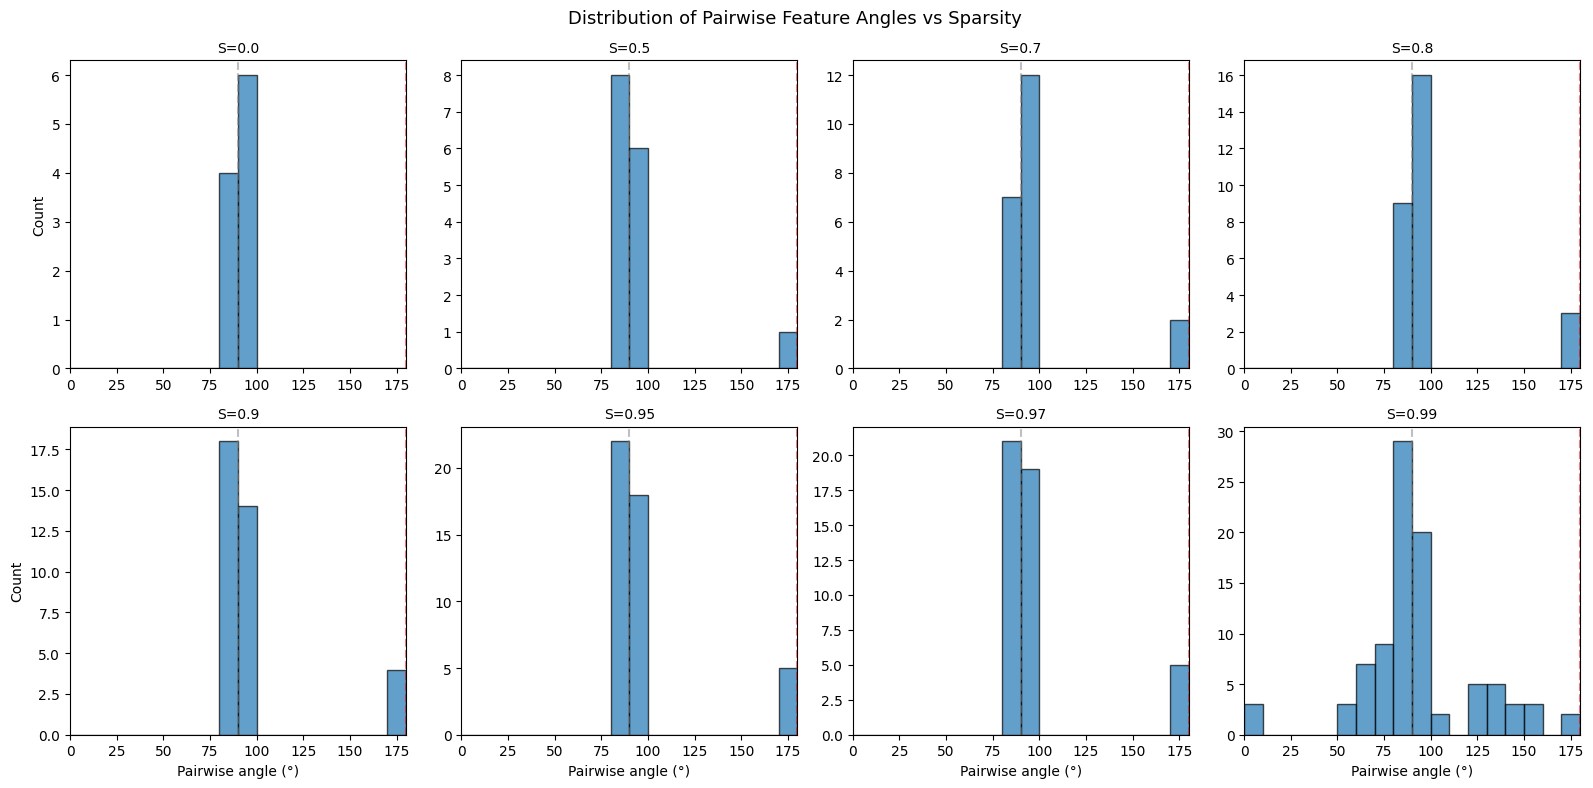

In [7]:
# Look for antipodal pairs in the S=0.9 model
# Two features are antipodal if their angle is close to 180°

def analyze_feature_pairs(model, threshold_angle=150):
    """Find near-antipodal and near-parallel feature pairs."""
    W = list(model.encoder.parameters())[0].detach().cpu().numpy()  # m x n
    n_features = W.shape[1]
    
    pairs = []
    for i in range(n_features):
        for j in range(i+1, n_features):
            wi, wj = W[:, i], W[:, j]
            ni, nj = np.linalg.norm(wi), np.linalg.norm(wj)
            if ni > 0.1 and nj > 0.1:  # both represented
                cos = np.dot(wi, wj) / (ni * nj)
                angle = np.arccos(np.clip(cos, -1, 1)) * 180 / np.pi
                pairs.append((i, j, angle, ni, nj))
    
    pairs.sort(key=lambda x: x[2])  # sort by angle
    
    print(f"Feature pairs (both norms > 0.1):")
    print(f"  Near-parallel (< 30°):")
    for i, j, angle, ni, nj in pairs:
        if angle < 30:
            print(f"    f{i}-f{j}: {angle:.1f}° (norms {ni:.2f}, {nj:.2f})")
    
    print(f"  Near-antipodal (> {threshold_angle}°):")
    for i, j, angle, ni, nj in pairs:
        if angle > threshold_angle:
            print(f"    f{i}-f{j}: {angle:.1f}° (norms {ni:.2f}, {nj:.2f})")
    
    # Distribution
    angles = [p[2] for p in pairs]
    return angles

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, S in enumerate(S_values):
    print(f"\n--- S = {S} ---")
    angles = analyze_feature_pairs(models_by_S[S]['model'])
    
    ax = axes[idx]
    if angles:
        ax.hist(angles, bins=18, range=(0, 180), edgecolor='black', alpha=0.7)
    ax.set_xlim(0, 180)
    ax.set_title(f'S={S}', fontsize=10)
    ax.set_xlabel('Pairwise angle (°)' if idx >= 4 else '')
    ax.set_ylabel('Count' if idx % 4 == 0 else '')
    # Mark key angles
    ax.axvline(90, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(180, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Distribution of Pairwise Feature Angles vs Sparsity', fontsize=13)
plt.tight_layout()
plt.show()

---
# Part 2: Depth and Nonlinear Encoding

Now the key question for our project: how does adding depth (l > 1, nonlinear encoder) change superposition behavior?

Hypotheses:
1. **Depth might not change superposition much for sparse uncorrelated features**: The l=1 model already achieves near-optimal packing, and deeper models may just learn the same linear solution.
2. **Depth could help when features are correlated**: Nonlinear encoders might learn to "disentangle" correlated features before compressing.
3. **Depth could enable denser packing**: More expressive encoders might pack more features into the same bottleneck.

## 2.1 W^TW Comparison: l=1 vs l=2 vs l=3

In [8]:
# For deeper models, W^TW doesn't directly apply (encoder is nonlinear).
# Instead, measure the effective encoding geometry by computing the 
# Gram matrix of encoder(e_i) for each standard basis vector e_i.

def compute_encoding_gram(model, n_features):
    """Compute Gram matrix of encoded standard basis vectors.
    
    For l=1, this is equivalent to W^TW.
    For l>1, this captures the nonlinear encoding geometry.
    """
    model.eval()
    with torch.no_grad():
        # Encode each standard basis vector
        eye = torch.eye(n_features, device=device)
        z = model.encode(eye)  # n x m
        
        # Normalize for Gram matrix
        norms = z.norm(dim=1, keepdim=True)
        z_normed = z / (norms + 1e-8)
        
        # Gram matrix
        gram = (z_normed @ z_normed.T).cpu().numpy()
        norms_np = norms.squeeze().cpu().numpy()
        
    return gram, norms_np, z.cpu().numpy()


# Train across depth and sparsity
n_fixed = 20
m_fixed = 5
l_values = [1, 2, 3]
S_subset = [0.0, 0.7, 0.9, 0.97]

depth_models = {}

for l in l_values:
    for S in tqdm(S_subset, desc=f"l={l}"):
        tied = (l == 1)
        result = run_experiment_multi_seed(
            n=n_fixed, m=m_fixed, l=l,
            n_seeds=30,
            S=S,
            n_steps=15000,
            importance_decay=0.7,
            tied_weights=tied,
            verbose=False
        )
        depth_models[(l, S)] = result
        print(f"  l={l}, S={S}: loss={result['final_loss']:.6f}")

l=1:   0%|          | 0/4 [00:00<?, ?it/s]

l=1:  25%|██▌       | 1/4 [01:52<05:38, 112.77s/it]

  l=1, S=0.0: loss=0.002317


l=1:  50%|█████     | 2/4 [03:45<03:45, 112.66s/it]

  l=1, S=0.7: loss=0.001673


...

l=3:  75%|███████▌  | 3/4 [12:14<04:04, 244.39s/it]

  l=3, S=0.9: loss=0.000119


l=3: 100%|██████████| 4/4 [16:22<00:00, 245.90s/it]

l=3: 100%|██████████| 4/4 [16:22<00:00, 245.63s/it]

  l=3, S=0.97: loss=0.000095


/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_18095/1458602384.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


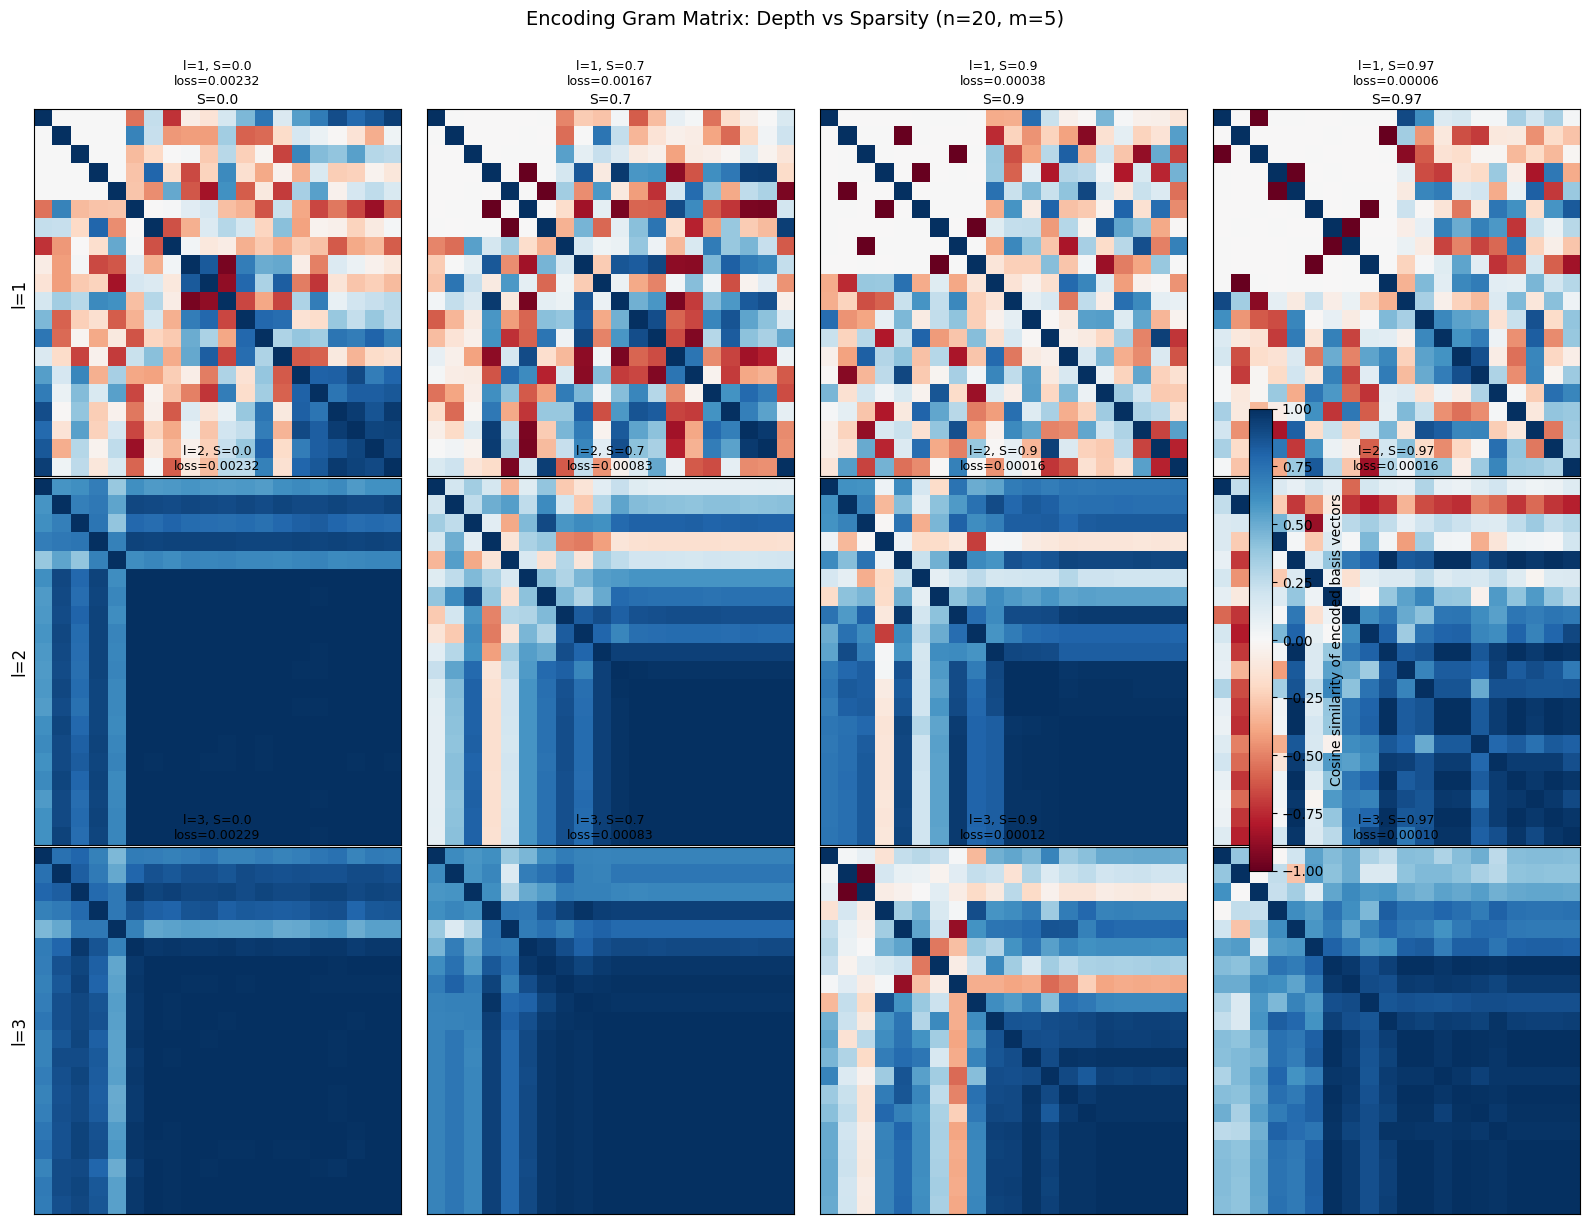

In [9]:
# Compare encoding Gram matrices across depth
fig, axes = plt.subplots(len(l_values), len(S_subset), figsize=(4*len(S_subset), 4*len(l_values)))

for row, l in enumerate(l_values):
    for col, S in enumerate(S_subset):
        model = depth_models[(l, S)]['model']
        gram, norms, z_basis = compute_encoding_gram(model, n_fixed)
        
        ax = axes[row, col]
        im = ax.imshow(gram, cmap='RdBu', vmin=-1, vmax=1, aspect='equal')
        ax.set_title(f'l={l}, S={S}\nloss={depth_models[(l,S)]["final_loss"]:.5f}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f'l={l}', fontsize=12)
        if row == 0:
            ax.set_xlabel(f'S={S}', fontsize=10)
            ax.xaxis.set_label_position('top')

fig.colorbar(im, ax=axes, shrink=0.5, label='Cosine similarity of encoded basis vectors')
fig.suptitle(f'Encoding Gram Matrix: Depth vs Sparsity (n={n_fixed}, m={m_fixed})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Quantitative comparison: number of represented features and loss
print(f"{'l':>3} {'S':>5} {'loss':>10} {'n_repr':>7} {'nonlin_gain':>12}")
print("-" * 45)

depth_comparison = []
for l in l_values:
    for S in S_subset:
        result = depth_models[(l, S)]
        model = result['model']
        gram, norms, z_basis = compute_encoding_gram(model, n_fixed)
        n_repr = np.sum(norms > 0.1)
        
        # Measure nonlinear gain
        metrics = measure_encoding_linearity(model, S=S)
        
        print(f"{l:>3} {S:>5.2f} {result['final_loss']:>10.6f} {n_repr:>7} {metrics['nonlinear_gain']:>12.4f}")
        
        depth_comparison.append({
            'l': l, 'S': S,
            'loss': result['final_loss'],
            'n_represented': n_repr,
            'nonlinear_gain': metrics['nonlinear_gain'],
            'mse_full': metrics['mse_full'],
            'mse_linear': metrics['mse_linear'],
        })

depth_df = pd.DataFrame(depth_comparison)

  l     S       loss  n_repr  nonlin_gain
---------------------------------------------


  1  0.00   0.002317       5       0.0000
  1  0.70   0.001673       7       0.0000
  1  0.90   0.000378       9       0.0000
  1  0.97   0.000062      10       0.0000
  2  0.00   0.002324      20       0.0000
  2  0.70   0.000835      20       0.1786
  2  0.90   0.000162      20       0.0587
  2  0.97   0.000163      20       0.0239
  3  0.00   0.002287      20       0.0000
  3  0.70   0.000832      20       0.0708
  3  0.90   0.000119      20       0.2137
  3  0.97   0.000095      20       0.0221


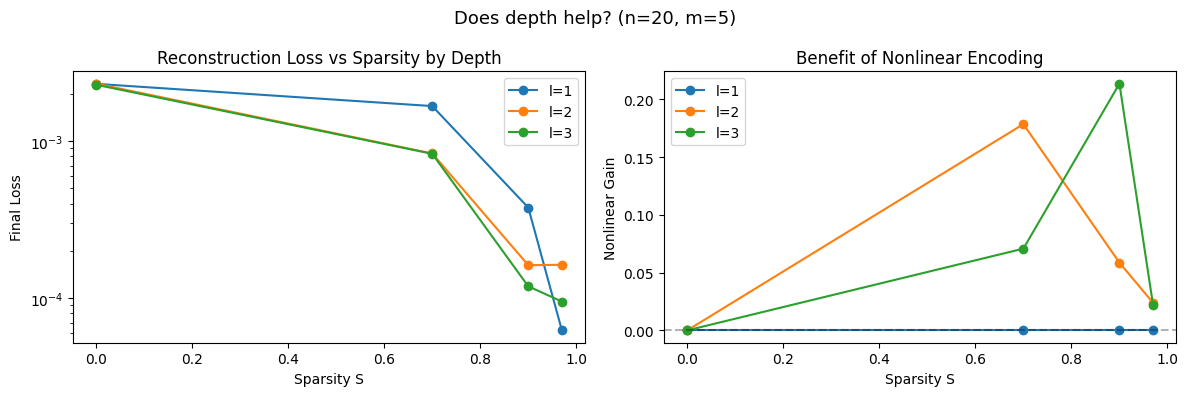

In [11]:
# Plot loss comparison across depth for each sparsity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for l in l_values:
    subset = depth_df[depth_df['l'] == l]
    ax.plot(subset['S'], subset['loss'], 'o-', label=f'l={l}', markersize=6)
ax.set_xlabel('Sparsity S')
ax.set_ylabel('Final Loss')
ax.set_title('Reconstruction Loss vs Sparsity by Depth')
ax.legend()
ax.set_yscale('log')

ax = axes[1]
for l in l_values:
    subset = depth_df[depth_df['l'] == l]
    ax.plot(subset['S'], subset['nonlinear_gain'], 'o-', label=f'l={l}', markersize=6)
ax.set_xlabel('Sparsity S')
ax.set_ylabel('Nonlinear Gain')
ax.set_title('Benefit of Nonlinear Encoding')
ax.legend()
ax.axhline(0, color='k', linestyle='--', alpha=0.3)

plt.suptitle(f'Does depth help? (n={n_fixed}, m={m_fixed})', fontsize=13)
plt.tight_layout()
plt.show()

## 2.2 Correlated Features

Real-world features aren't independent. The Toy Models paper explores correlated features briefly but doesn't go deep.

Key question: **Does nonlinear encoding help more when features are correlated?**

Setup: Generate features as linear combinations of a smaller set of "true" features.
- n = 20 observed features
- n_true = 10 underlying sources (so features have correlations)
- Compare l=1 (can't exploit correlations in encoder) vs l=2,3 (can)

In [12]:
# Custom training function that accepts a data generator
def train_with_generator(model, data_fn, n_steps=15000, lr=1e-3,
                         weight_decay=1e-2, importance=None, batch_size=1024,
                         verbose=True):
    """Train autoencoder with custom data generation function."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = data_fn(batch_size)
        
        optimizer.zero_grad()
        x_recon, z = model(x)
        
        if importance is not None:
            loss = (importance * (x - x_recon) ** 2).mean()
        else:
            loss = nn.functional.mse_loss(x_recon, x)
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if verbose and step % 2000 == 0:
            iterator.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return losses


# Compare independent vs correlated features across depth
n_obs = 20
m_bottle = 5
n_true_features = 10  # half the observed features
S_test = 0.9
l_values_test = [1, 2, 3]
n_seeds = 10

corr_results = []

for data_type in ['independent', 'correlated']:
    for l in l_values_test:
        seed_losses = []
        for seed in tqdm(range(n_seeds), desc=f'{data_type} l={l}'):
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            tied = (l == 1)
            model = Autoencoder(n_obs, m_bottle, l, tied_weights=tied).to(device)
            
            if data_type == 'independent':
                data_fn = lambda bs: generate_sparse_data(bs, n_obs, S_test)
            else:
                data_fn = lambda bs: generate_correlated_features(bs, n_obs, n_true_features, S_test)
            
            losses = train_with_generator(model, data_fn, n_steps=15000, verbose=False)
            final_loss = np.mean(losses[-100:])
            seed_losses.append(final_loss)
        
        best_loss = min(seed_losses)
        median_loss = np.median(seed_losses)
        
        corr_results.append({
            'data_type': data_type,
            'l': l,
            'best_loss': best_loss,
            'median_loss': median_loss,
            'all_losses': seed_losses
        })
        print(f"{data_type:>12} l={l}: best={best_loss:.6f}, median={median_loss:.6f}")

corr_df = pd.DataFrame(corr_results)

independent l=1:   0%|          | 0/10 [00:00<?, ?it/s]

independent l=1:  10%|█         | 1/10 [00:02<00:26,  2.92s/it]

independent l=1:  20%|██        | 2/10 [00:05<00:23,  2.91s/it]

independent l=1:  30%|███       | 3/10 [00:08<00:20,  2.90s/it]

independent l=1:  40%|████      | 4/10 [00:11<00:17,  2.91s/it]

...

correlated l=3:  80%|████████  | 8/10 [00:56<00:14,  7.05s/it]

correlated l=3:  90%|█████████ | 9/10 [01:03<00:07,  7.04s/it]

correlated l=3: 100%|██████████| 10/10 [01:10<00:00,  7.03s/it]

correlated l=3: 100%|██████████| 10/10 [01:10<00:00,  7.04s/it]

  correlated l=3: best=0.025853, median=0.026565


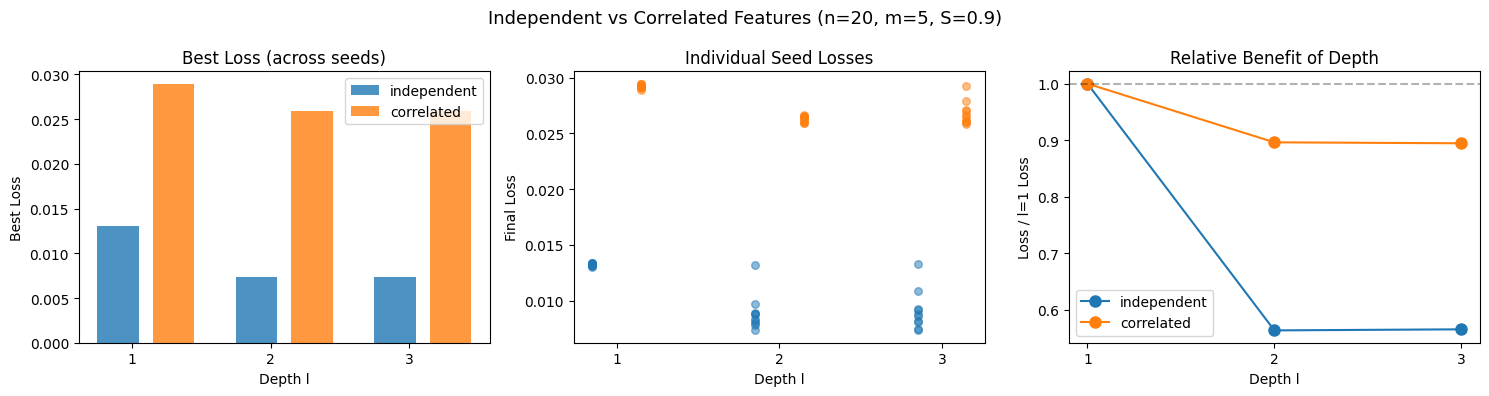


Key question: Does the relative benefit of depth differ between
independent and correlated features? If correlated line drops more,
depth helps exploit correlations.


In [13]:
# Visualize: does depth help more for correlated features?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Best loss by depth and data type
ax = axes[0]
for dt in ['independent', 'correlated']:
    subset = corr_df[corr_df['data_type'] == dt]
    ax.bar([l + (0.3 if dt == 'correlated' else -0.1) for l in subset['l']],
           subset['best_loss'], width=0.3, label=dt, alpha=0.8)
ax.set_xlabel('Depth l')
ax.set_ylabel('Best Loss')
ax.set_title('Best Loss (across seeds)')
ax.legend()
ax.set_xticks(l_values_test)

# Plot 2: Individual seed losses
ax = axes[1]
for idx, row in corr_df.iterrows():
    x_pos = row['l'] + (0.15 if row['data_type'] == 'correlated' else -0.15)
    color = 'C1' if row['data_type'] == 'correlated' else 'C0'
    ax.scatter([x_pos] * len(row['all_losses']), row['all_losses'],
               alpha=0.5, color=color, s=30)
ax.set_xlabel('Depth l')
ax.set_ylabel('Final Loss')
ax.set_title('Individual Seed Losses')
ax.set_xticks(l_values_test)

# Plot 3: Relative improvement from depth (normalized to l=1)
ax = axes[2]
for dt in ['independent', 'correlated']:
    subset = corr_df[corr_df['data_type'] == dt]
    baseline = subset[subset['l'] == 1]['best_loss'].values[0]
    relative = subset['best_loss'] / baseline
    ax.plot(subset['l'], relative, 'o-', label=dt, markersize=8)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Depth l')
ax.set_ylabel('Loss / l=1 Loss')
ax.set_title('Relative Benefit of Depth')
ax.legend()
ax.set_xticks(l_values_test)

plt.suptitle(f'Independent vs Correlated Features (n={n_obs}, m={m_bottle}, S={S_test})',
             fontsize=13)
plt.tight_layout()
plt.show()

print("\nKey question: Does the relative benefit of depth differ between")
print("independent and correlated features? If correlated line drops more,")
print("depth helps exploit correlations.")

## 2.3 Sparsity × Depth Interaction

Systematic sweep: does the benefit of depth depend on sparsity?

Intuition: At high sparsity, the data distribution is simpler (mostly zeros), so a linear encoder might suffice. At low sparsity, more features are simultaneously active and might benefit from nonlinear encoding.

In [14]:
# Sweep: sparsity × depth for fixed n, m
n_fixed, m_fixed = 20, 5
S_sweep_fine = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
l_sweep = [1, 2, 3]

interaction_data = []

for l in l_sweep:
    for S in tqdm(S_sweep_fine, desc=f"l={l}"):
        tied = (l == 1)
        result = run_experiment_multi_seed(
            n=n_fixed, m=m_fixed, l=l,
            n_seeds=20,
            S=S,
            n_steps=15000,
            importance_decay=0.7,
            tied_weights=tied,
            verbose=False
        )
        
        metrics = measure_encoding_linearity(result['model'], S=S)
        
        interaction_data.append({
            'l': l, 'S': S,
            'loss': result['final_loss'],
            'nonlinear_gain': metrics['nonlinear_gain'],
            'mse_full': metrics['mse_full'],
            'mse_linear': metrics['mse_linear'],
        })

interaction_df = pd.DataFrame(interaction_data)
print("Sweep complete.")

l=1:   0%|          | 0/8 [00:00<?, ?it/s]

l=1:  12%|█▎        | 1/8 [01:16<08:53, 76.22s/it]

l=1:  25%|██▌       | 2/8 [02:32<07:36, 76.07s/it]

l=1:  38%|███▊      | 3/8 [03:47<06:19, 75.87s/it]

l=1:  50%|█████     | 4/8 [05:02<05:02, 75.53s/it]

...

l=3:  75%|███████▌  | 6/8 [16:14<05:24, 162.40s/it]

l=3:  88%|████████▊ | 7/8 [18:55<02:42, 162.09s/it]

l=3: 100%|██████████| 8/8 [21:37<00:00, 162.07s/it]

l=3: 100%|██████████| 8/8 [21:37<00:00, 162.22s/it]

Sweep complete.


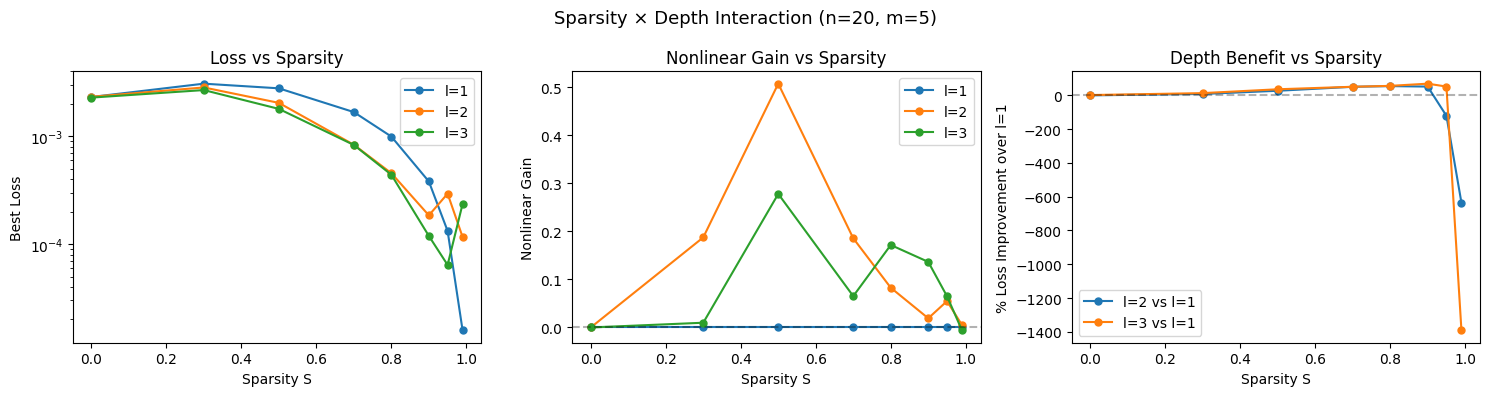


Look for: Does depth benefit peak at some sparsity level?
If so, that's where nonlinear encoding matters most.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Loss vs sparsity by depth
ax = axes[0]
for l in l_sweep:
    subset = interaction_df[interaction_df['l'] == l]
    ax.plot(subset['S'], subset['loss'], 'o-', label=f'l={l}', markersize=5)
ax.set_xlabel('Sparsity S')
ax.set_ylabel('Best Loss')
ax.set_title('Loss vs Sparsity')
ax.legend()
ax.set_yscale('log')

# Plot 2: Nonlinear gain vs sparsity by depth
ax = axes[1]
for l in l_sweep:
    subset = interaction_df[interaction_df['l'] == l]
    ax.plot(subset['S'], subset['nonlinear_gain'], 'o-', label=f'l={l}', markersize=5)
ax.set_xlabel('Sparsity S')
ax.set_ylabel('Nonlinear Gain')
ax.set_title('Nonlinear Gain vs Sparsity')
ax.legend()
ax.axhline(0, color='k', linestyle='--', alpha=0.3)

# Plot 3: Depth benefit = loss_l1 / loss_l - 1 
ax = axes[2]
l1_losses = interaction_df[interaction_df['l'] == 1].set_index('S')['loss']
for l in [2, 3]:
    subset = interaction_df[interaction_df['l'] == l].set_index('S')['loss']
    # Positive = depth helps, negative = depth hurts
    benefit = (l1_losses - subset) / l1_losses * 100  # percent improvement
    ax.plot(benefit.index, benefit.values, 'o-', label=f'l={l} vs l=1', markersize=5)
ax.set_xlabel('Sparsity S')
ax.set_ylabel('% Loss Improvement over l=1')
ax.set_title('Depth Benefit vs Sparsity')
ax.legend()
ax.axhline(0, color='k', linestyle='--', alpha=0.3)

plt.suptitle(f'Sparsity × Depth Interaction (n={n_fixed}, m={m_fixed})', fontsize=13)
plt.tight_layout()
plt.show()

print("\nLook for: Does depth benefit peak at some sparsity level?")
print("If so, that's where nonlinear encoding matters most.")

## 2.4 Higher Compression Regime

The above uses n=20, m=5 (4x compression). Let's also check higher compression where superposition is forced, and lower compression where it's not needed.

In [16]:
# Sweep compression ratio at fixed high sparsity
n_fixed = 40
S_fixed = 0.95
m_sweep = [2, 5, 10, 20, 30, 38]

compression_data = []

for l in [1, 2, 3]:
    for m_val in tqdm(m_sweep, desc=f"l={l}"):
        tied = (l == 1)
        result = run_experiment_multi_seed(
            n=n_fixed, m=m_val, l=l,
            n_seeds=20,
            S=S_fixed,
            n_steps=15000,
            importance_decay=0.7,
            tied_weights=tied,
            verbose=False
        )
        
        metrics = measure_encoding_linearity(result['model'], S=S_fixed)
        model = result['model']
        gram, norms, z_basis = compute_encoding_gram(model, n_fixed)
        n_repr = np.sum(norms > 0.1)
        
        compression_data.append({
            'l': l, 'm': m_val,
            'n_over_m': n_fixed / m_val,
            'loss': result['final_loss'],
            'nonlinear_gain': metrics['nonlinear_gain'],
            'n_represented': n_repr,
            'superposition_ratio': n_repr / m_val,
        })

comp_df = pd.DataFrame(compression_data)

l=1:   0%|          | 0/6 [00:00<?, ?it/s]

l=1:  17%|█▋        | 1/6 [04:15<21:15, 255.14s/it]

l=1:  33%|███▎      | 2/6 [08:37<17:16, 259.25s/it]

l=1:  50%|█████     | 3/6 [13:18<13:27, 269.18s/it]

l=1:  67%|██████▋   | 4/6 [17:55<09:04, 272.41s/it]

...

l=3:  50%|█████     | 3/6 [1:44:56<1:41:04, 2021.50s/it]

l=3:  67%|██████▋   | 4/6 [1:50:19<45:02, 1351.20s/it]  

l=3:  83%|████████▎ | 5/6 [1:55:44<16:21, 981.07s/it] 

l=3: 100%|██████████| 6/6 [2:02:21<00:00, 782.32s/it]

l=3: 100%|██████████| 6/6 [2:02:21<00:00, 1223.51s/it]

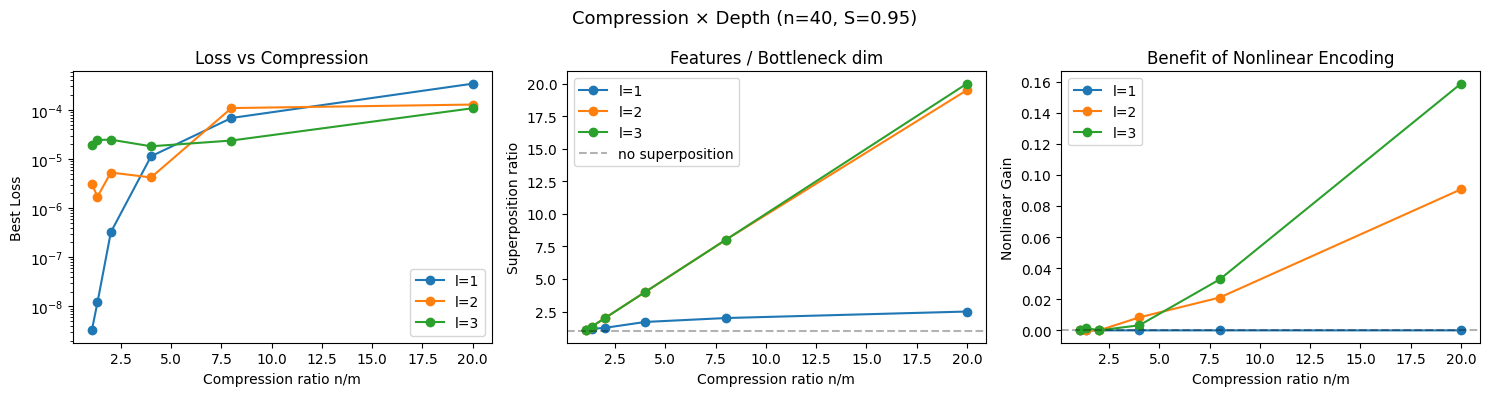

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Loss vs compression
ax = axes[0]
for l in [1, 2, 3]:
    subset = comp_df[comp_df['l'] == l]
    ax.plot(subset['n_over_m'], subset['loss'], 'o-', label=f'l={l}')
ax.set_xlabel('Compression ratio n/m')
ax.set_ylabel('Best Loss')
ax.set_title('Loss vs Compression')
ax.legend()
ax.set_yscale('log')

# Plot 2: Superposition ratio
ax = axes[1]
for l in [1, 2, 3]:
    subset = comp_df[comp_df['l'] == l]
    ax.plot(subset['n_over_m'], subset['superposition_ratio'], 'o-', label=f'l={l}')
ax.axhline(1, color='k', linestyle='--', alpha=0.3, label='no superposition')
ax.set_xlabel('Compression ratio n/m')
ax.set_ylabel('Superposition ratio')
ax.set_title('Features / Bottleneck dim')
ax.legend()

# Plot 3: Nonlinear gain
ax = axes[2]
for l in [1, 2, 3]:
    subset = comp_df[comp_df['l'] == l]
    ax.plot(subset['n_over_m'], subset['nonlinear_gain'], 'o-', label=f'l={l}')
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Compression ratio n/m')
ax.set_ylabel('Nonlinear Gain')
ax.set_title('Benefit of Nonlinear Encoding')
ax.legend()

plt.suptitle(f'Compression × Depth (n={n_fixed}, S={S_fixed})', fontsize=13)
plt.tight_layout()
plt.show()

## 2.5 Summary and Interpretation

In [18]:
# Print summary table
print("="*70)
print("SUMMARY: Sparsity × Depth × Correlation Interactions")
print("="*70)

print("\n--- Depth benefit at different sparsity levels (n=20, m=5) ---")
for S in S_sweep_fine:
    l1 = interaction_df[(interaction_df['l']==1) & (interaction_df['S']==S)]['loss'].values
    l3 = interaction_df[(interaction_df['l']==3) & (interaction_df['S']==S)]['loss'].values
    if len(l1) > 0 and len(l3) > 0:
        pct = (l1[0] - l3[0]) / l1[0] * 100
        print(f"  S={S:.2f}: l=1 loss={l1[0]:.6f}, l=3 loss={l3[0]:.6f}, "
              f"depth benefit={pct:+.1f}%")

print("\n--- Correlation effect ---")
for row_idx, row in corr_df.iterrows():
    print(f"  {row['data_type']:>12} l={row['l']}: best={row['best_loss']:.6f}")

print("\n" + "="*70)
print("Qualitative findings (to be confirmed by the plots above):")
print("1. Does depth help more at low or high sparsity?")
print("2. Does depth help more for correlated or independent features?")
print("3. At what compression ratio does nonlinear encoding become beneficial?")
print("="*70)

SUMMARY: Sparsity × Depth × Correlation Interactions

--- Depth benefit at different sparsity levels (n=20, m=5) ---
  S=0.00: l=1 loss=0.002317, l=3 loss=0.002287, depth benefit=+1.3%
  S=0.30: l=1 loss=0.003080, l=3 loss=0.002687, depth benefit=+12.8%
  S=0.50: l=1 loss=0.002789, l=3 loss=0.001797, depth benefit=+35.6%
  S=0.70: l=1 loss=0.001678, l=3 loss=0.000832, depth benefit=+50.5%
  S=0.80: l=1 loss=0.000995, l=3 loss=0.000440, depth benefit=+55.8%
  S=0.90: l=1 loss=0.000381, l=3 loss=0.000119, depth benefit=+68.8%
  S=0.95: l=1 loss=0.000132, l=3 loss=0.000064, depth benefit=+51.6%
  S=0.99: l=1 loss=0.000016, l=3 loss=0.000236, depth benefit=-1391.6%

--- Correlation effect ---
   independent l=1: best=0.013002
   independent l=2: best=0.007331
   independent l=3: best=0.007355
    correlated l=1: best=0.028899
    correlated l=2: best=0.025902
    correlated l=3: best=0.025853

Qualitative findings (to be confirmed by the plots above):
1. Does depth help more at low or high